In [1]:
import random

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from mpl_finance import candlestick_ohlc
import matplotlib.dates as mdates

from binance import Client

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

/opt/homebrew/Caskroom/miniforge/base/envs/coin/lib/python3.9/site-packages/mpl_finance.py:16: DeprecationWarning: 



    Please use `mplfinance` instead (no hyphen, no underscore).

    To install: `pip install --upgrade mplfinance` 

   For more information, see: https://pypi.org/project/mplfinance/


  __warnings.warn('\n\n  ================================================================='+


In [2]:
# Hyperparameters
learning_rate = 0.0003
gamma = 0.95

In [3]:
client = Client()
klines = np.array(client.get_historical_klines("ETHUSDT", Client.KLINE_INTERVAL_1HOUR, "1 Jan, 2016"))
sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime',
                                                                   'open',
                                                                   'high',
                                                                   'low',
                                                                   'close',
                                                                   'volume',
                                                                   'close time',
                                                                   'quote asset volume, number of trades',
                                                                   'number of trades',
                                                                   'taker buy base asset volume',
                                                                   'taker buy quote asset volume',
                                                                   'ignore'])
sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
sample.set_index('datetime', inplace=True)
sample = sample[['open', 'high', 'low', 'close', 'volume']]

In [4]:
# make states
sample['ropen_7'] = (sample['open'] - sample['low'].rolling(7).min())/(sample['high'].rolling(7).max() - sample['low'].rolling(7).min())
sample['rhigh_7'] = (sample['high'] - sample['low'].rolling(7).min())/(sample['high'].rolling(7).max() - sample['low'].rolling(7).min())
sample['rlow_7'] = (sample['low'] - sample['low'].rolling(7).min())/(sample['high'].rolling(7).max() - sample['low'].rolling(7).min())
sample['rclose_7'] = (sample['close'] - sample['low'].rolling(7).min())/(sample['high'].rolling(7).max() - sample['low'].rolling(7).min())
sample['rvolume_7'] = (sample['volume'] - sample['volume'].rolling(7).min())/(sample['volume'].rolling(7).max() - sample['volume'].rolling(7).min())

sample['ropen_14'] = (sample['open'] - sample['low'].rolling(14).min())/(sample['high'].rolling(14).max() - sample['low'].rolling(14).min())
sample['rhigh_14'] = (sample['high'] - sample['low'].rolling(14).min())/(sample['high'].rolling(14).max() - sample['low'].rolling(14).min())
sample['rlow_14'] = (sample['low'] - sample['low'].rolling(14).min())/(sample['high'].rolling(14).max() - sample['low'].rolling(14).min())
sample['rclose_14'] = (sample['close'] - sample['low'].rolling(14).min())/(sample['high'].rolling(14).max() - sample['low'].rolling(14).min())
sample['rvolume_14'] = (sample['volume'] - sample['volume'].rolling(14).min())/(sample['volume'].rolling(14).max() - sample['volume'].rolling(14).min())

sample['ropen_24'] = (sample['open'] - sample['low'].rolling(24).min())/(sample['high'].rolling(24).max() - sample['low'].rolling(24).min())
sample['rhigh_24'] = (sample['high'] - sample['low'].rolling(24).min())/(sample['high'].rolling(24).max() - sample['low'].rolling(24).min())
sample['rlow_24'] = (sample['low'] - sample['low'].rolling(24).min())/(sample['high'].rolling(24).max() - sample['low'].rolling(24).min())
sample['rclose_24'] = (sample['close'] - sample['low'].rolling(24).min())/(sample['high'].rolling(24).max() - sample['low'].rolling(24).min())
sample['rvolume_24'] = (sample['volume'] - sample['volume'].rolling(24).min())/(sample['volume'].rolling(24).max() - sample['volume'].rolling(24).min())

sample['ropen_168'] = (sample['open'] - sample['low'].rolling(168).min())/(sample['high'].rolling(168).max() - sample['low'].rolling(168).min())
sample['rhigh_168'] = (sample['high'] - sample['low'].rolling(168).min())/(sample['high'].rolling(168).max() - sample['low'].rolling(168).min())
sample['rlow_168'] = (sample['low'] - sample['low'].rolling(168).min())/(sample['high'].rolling(168).max() - sample['low'].rolling(168).min())
sample['rclose_168'] = (sample['close'] - sample['low'].rolling(168).min())/(sample['high'].rolling(168).max() - sample['low'].rolling(168).min())
sample['rvolume_168'] = (sample['volume'] - sample['volume'].rolling(168).min())/(sample['volume'].rolling(168).max() - sample['volume'].rolling(168).min())

sample['ropen_1500'] = (sample['open'] - sample['low'].rolling(1500).min())/(sample['high'].rolling(1500).max() - sample['low'].rolling(1500).min())
sample['rhigh_1500'] = (sample['high'] - sample['low'].rolling(1500).min())/(sample['high'].rolling(1500).max() - sample['low'].rolling(1500).min())
sample['rlow_1500'] = (sample['low'] - sample['low'].rolling(1500).min())/(sample['high'].rolling(1500).max() - sample['low'].rolling(1500).min())
sample['rclose_1500'] = (sample['close'] - sample['low'].rolling(1500).min())/(sample['high'].rolling(1500).max() - sample['low'].rolling(1500).min())
sample['rvolume_1500'] = (sample['volume'] - sample['volume'].rolling(1500).min())/(sample['volume'].rolling(1500).max() - sample['volume'].rolling(1500).min())

sample.dropna(inplace=True)

In [5]:
cut1 = int(len(sample)*0.8)
cut2 = int(len(sample)*0.85)
train_sample, val_sample, test_sample = sample.iloc[:cut1], sample.iloc[cut1:cut2], sample.iloc[cut2:]

In [6]:
class Environment():
    def __init__(self, sample):
        self.sample = sample.copy()
        self.episode = None
        self.epi_idx = 0
        
    def make_episode(self, start_idx=-1):
        if start_idx > len(self.sample) - 2000:
            print(f"start_idx should be smaller than {len(self.sample)-2000}")
            raise(ValueError)
        if start_idx == -1: start_idx = random.randint(0, len(self.sample)-2000)
        
        self.episode = self.sample[start_idx:start_idx+2000]
        self.epi_idx = 0
        first_state = self.episode.iloc[self.epi_idx].to_numpy()[5:]
        return first_state
    
    def step(self, action):
        this_close = self.episode.iloc[self.epi_idx].to_numpy()[3]
    
        self.epi_idx += 1
        
        # is done?
        done = True if self.epi_idx == 2000-1 else False
        
        #print(len(self.episode), self.epi_idx)
        # make state
        state = self.episode.iloc[self.epi_idx].to_numpy()[5:]
        
        # make reward
        next_high = self.episode.iloc[self.epi_idx].to_numpy()[1]
        next_low = self.episode.iloc[self.epi_idx].to_numpy()[2]
        reward = np.log(random.uniform(next_low, next_high)/this_close)
        
        if action == 0: reward = 0.
        
        # index and ohlcv
        info = (self.epi_idx, self.episode.iloc[self.epi_idx].to_numpy()[:5])
        
        return (state, reward, done, info)

In [7]:
class Policy(nn.Module):
    def __init__(self):
        super(Policy, self).__init__()
        self.data = []
        
        self.fc1 = nn.Linear(25, 128, bias=True)
        self.fc2 = nn.Linear(128, 128, bias=True)
        self.fc3 = nn.Linear(128, 2)
        self.dropout = nn.Dropout(p=0.2)
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)
        
        # history
        self.episodes = 0
        self.scores = list()
        self.loss = list()
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.softmax(self.fc3(x), dim=0)
        return x
    
    def put_data(self,item):
        self.data.append(item)
    
    def train_net(self):
        R = 0.
        self.optimizer.zero_grad()
        for r, prob in self.data[::-1]:
            R = r + gamma*R
            loss = -R*torch.log(prob)
            loss.backward()
        self.optimizer.step()
        self.data = []
        
        return loss.detach().numpy()
    

In [8]:
class History():
    def __init__(self):
        self.episodes = 0
        self.score = []
        self.loss = []
        self.evaluation = {}
        self.evaluation['index'] = []
        self.evaluation['CAGR'] = []
        self.evaluation['MDD'] = []
        self.evaluation['VOL'] = []
        self.evaluation['Sharpe'] = []
    
    def update(self, score, loss):
        self.episodes += 1
        self.score.append(score)
        self.loss.append(loss)
        
    def save_evaluation(self, index, args):
        CAGR, MDD, VOL, Sharpe = args
        self.evaluation['index'].append(index)
        self.evaluation['CAGR'].append(CAGR)
        self.evaluation['MDD'].append(MDD)
        self.evaluation['VOL'].append(VOL)
        self.evaluation['Sharpe'].append(Sharpe)
    
    def plot(self):
        plt.figure(figsize=(15, 8))
        plt.subplot(2, 1, 1)
        plt.plot(range(self.episodes), self.score, 'r--', label='score')
        plt.legend(loc='best')
        
        plt.subplot(2, 1, 2)
        plt.plot(range(self.episodes), self.loss, 'b--', label='loss')
        plt.legend(loc='best')
        
        plt.show()

In [9]:
def evaluate(sample, policy):
    states = sample.to_numpy()
    book = sample[['close']].copy()
    
    book['number'] = book.index.map(mdates.date2num)
    book['reward'] = 1.
    book['total_reward'] = 1.
    
    for i, idx in enumerate(book.index):
        if idx == book.index[-1]: break
        state = states[i][5:]
        prob = policy(torch.from_numpy(state).float()).detach().numpy()
        weight = prob[1]
        book.loc[idx, 'reward'] = weight*(book.shift(-1).loc[idx, 'close']/book.loc[idx, 'close'] - 1.) + 1.

    total_reward = 1. 
    for idx in book.index:
        total_reward *= book.loc[idx, 'reward']
        book.loc[idx, 'total_reward'] = total_reward
        
    CAGR = book['total_reward'].iloc[-1]**(365*24/len(book.index)) - 1.
    historical_max = book['total_reward'].cummax()
    daily_drawdown = book['total_reward']/historical_max - 1.
    historical_dd = daily_drawdown.cummin()
    MDD = historical_dd.min()
    VOL = np.std(book['reward'])*np.sqrt(365.*24)
    Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.*24))

    return (CAGR, MDD, VOL, Sharpe)

In [10]:
env = Environment(train_sample)
pi = Policy()
train_history = History()
val_history = History()
acc_score = 0.
print_interval = 20
estimate_interval = 1000

for n_epi in range(30000):
    score = 0.
    state = env.make_episode()
    done = False
    
    while not done:
        prob = pi(torch.from_numpy(state).float())
        m = Categorical(prob)
        action = m.sample()
        next_state, reward, done, info = env.step(action.item())
        pi.put_data((reward, prob[action]))
        state = next_state
        score += reward
    
    pi.train()
    loss = pi.train_net()
    train_history.update(score, loss)
    
    acc_score += score
    if n_epi%print_interval == 0 and n_epi != 0:
        print(f"[EPISODE {n_epi}] avg return: {(np.exp(acc_score/print_interval)-1)*100:.2f}%")
        acc_score = 0.
        
    # estimate train & validation set
    if n_epi%estimate_interval == 0:
        pi.eval()
        CAGR, MDD, VOL, Sharpe = evaluate(train_sample, pi)
        train_history.save_evaluation(n_epi, (CAGR, MDD, VOL, Sharpe))
        print(f"[EPISODE {n_epi}] train set: {CAGR:.2f}\t{MDD:.2f}\t{VOL:.2f}\t{Sharpe:.2f}")
        CAGR, MDD, VOL, Sharpe = evaluate(val_sample, pi) 
        val_history.save_evaluation(n_epi,(CAGR, MDD, VOL, Sharpe))
        print(f"[EPISODE {n_epi}] validation set: {CAGR:.2f}\t{MDD:.2f}\t{VOL:.2f}\t{Sharpe:.2f}")
        torch.save(pi.state_dict(), f"params/REINFORCE/policy_{n_epi}.pt")

train_history.plot()

[EPISODE 0] train set: 0.56	-0.75	0.58	15221.22
[EPISODE 0] validation set: -0.00	-0.37	0.78	11245.15
[EPISODE 20] avg return: -21.69%
[EPISODE 40] avg return: -21.15%
[EPISODE 60] avg return: -27.59%
[EPISODE 80] avg return: -19.50%
[EPISODE 100] avg return: -27.27%
[EPISODE 120] avg return: -21.77%
[EPISODE 140] avg return: -13.89%
[EPISODE 160] avg return: -15.74%
[EPISODE 180] avg return: -14.31%
[EPISODE 200] avg return: -11.88%
[EPISODE 220] avg return: -6.53%
[EPISODE 240] avg return: -9.10%
[EPISODE 260] avg return: -9.32%
[EPISODE 280] avg return: -5.79%
[EPISODE 300] avg return: -5.01%
[EPISODE 320] avg return: -7.51%
[EPISODE 340] avg return: -3.67%
[EPISODE 360] avg return: -4.35%
[EPISODE 380] avg return: 0.74%
[EPISODE 400] avg return: -2.15%
[EPISODE 420] avg return: -3.14%
[EPISODE 440] avg return: -0.72%
[EPISODE 460] avg return: -3.94%
[EPISODE 480] avg return: 0.39%
[EPISODE 500] avg return: 0.04%
[EPISODE 520] avg return: -0.75%
[EPISODE 540] avg return: -2.44%
[EPI

==== REINFORCE trading ====
Accumulated Returns: nan %
CAGR: nan %
MDD: -41.77 %
VOL: 20.772 %
Sharpe: 4217148.84 %


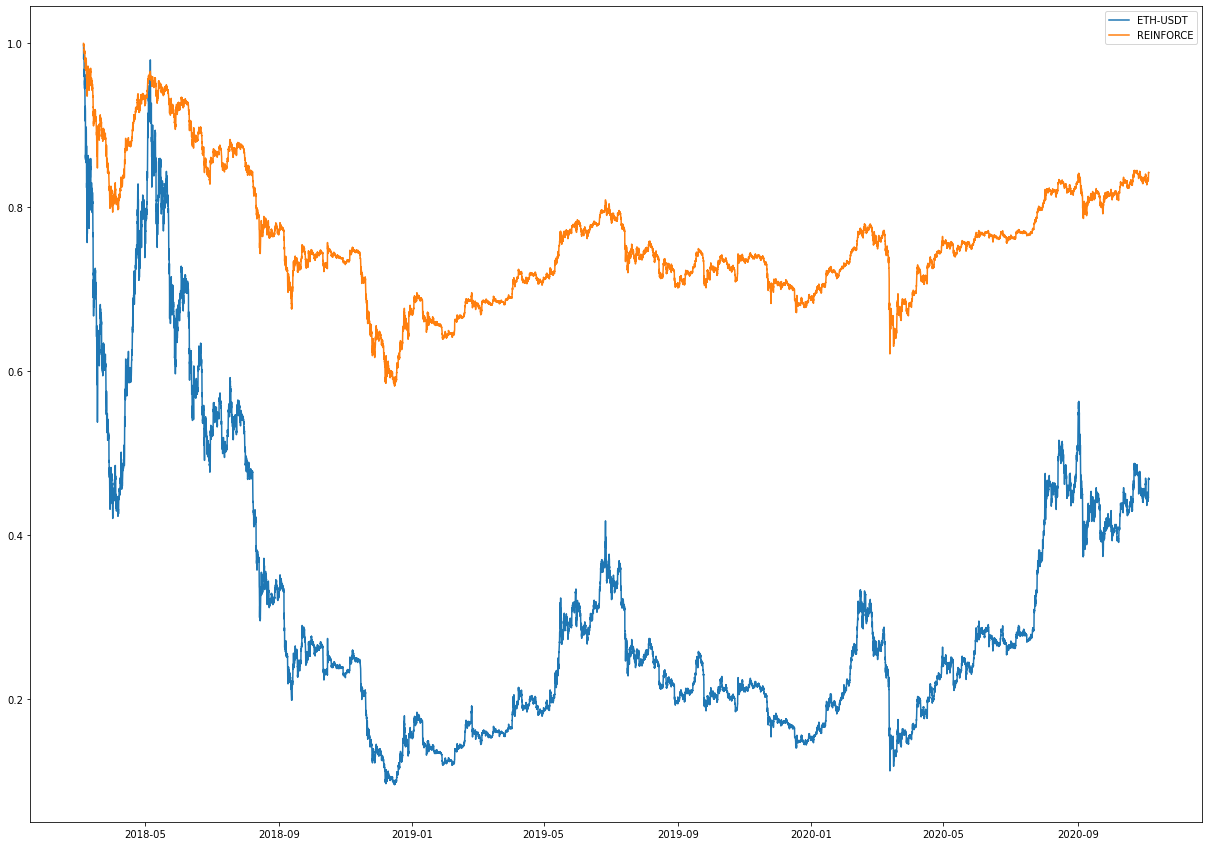

In [23]:
train_states = train_sample.to_numpy()
ref = train_sample[['close']].copy()
ref['number'] = ref.index.map(mdates.date2num)
ref['reward'] = 1. + ref['close'].pct_change()
ref['total_reward'] = ref['reward'].cumprod()

#  Buy and hold
book = train_sample[['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.
book['total_reward'] = 1.
book['action'] = False
for i, idx in enumerate(book.index):
    state = train_states[i][5:]
    prob = pi(torch.from_numpy(state).float()).detach().numpy()
    weight = prob[1]
    #m = Categorical(prob)
    #action = m.sample().item()
    #if action == 0:
    #    book.loc[idx, 'reward'] = 1.
    #else:
    #    book.loc[idx, 'action'] = True
    book.loc[idx, 'reward'] = weight*(train_sample.shift(-1).loc[idx, 'close']/train_sample.loc[idx, 'close'] - 1.) + 1.

total_reward = 1. 
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365*24/len(book.index)) - 1.
historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.*24)
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.*24))

print("==== REINFORCE trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

plt.figure(figsize=(21, 15))
#plt.yscale('log')
#for coin in samples.keys():
#    plt.plot(samples[coin].index, samples[coin].total_reward, label=coin)
plt.plot(ref.index, ref.total_reward, label="ETH-USDT")
plt.plot(book.index, book.total_reward, label="REINFORCE")
plt.legend(loc='best')

plt.show()

==== REINFORCE trading ====
Accumulated Returns: nan %
CAGR: nan %
MDD: -30.3 %
VOL: 68.509 %
Sharpe: 1279008.96 %


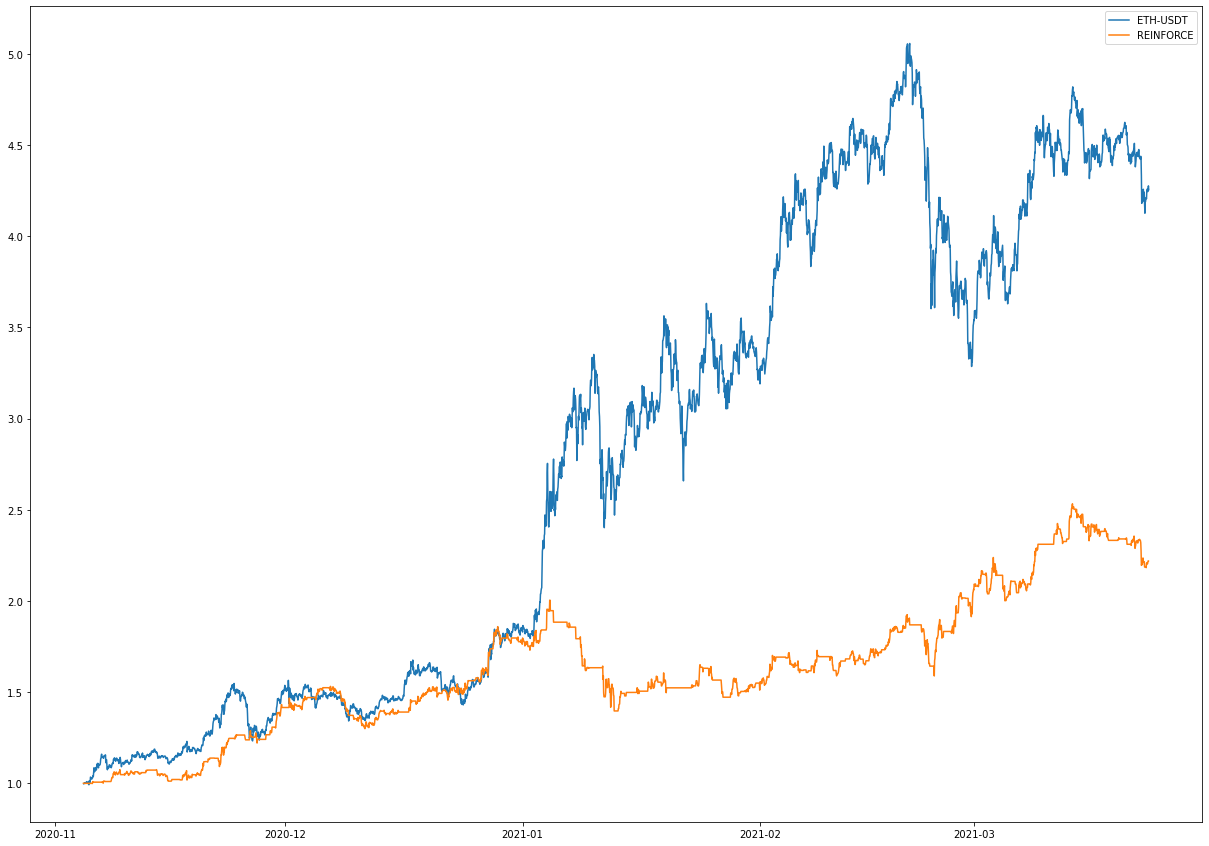

In [ ]:
val_states = val_sample.to_numpy()
ref = val_sample[['close']].copy()
ref['number'] = ref.index.map(mdates.date2num)
ref['reward'] = 1. + ref['close'].pct_change()
ref['total_reward'] = ref['reward'].cumprod()

#  Buy and hold
book = val_sample[['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.
book['total_reward'] = 1.
book['action'] = False
for i, idx in enumerate(book.index):
    state = train_states[i][5:]
    prob = pi(torch.from_numpy(state).float())
    m = Categorical(prob)
    action = m.sample().item()
    if action == 0:
        book.loc[idx, 'reward'] = 1.
    else:
        book.loc[idx, 'action'] = True
        book.loc[idx, 'reward'] = ref.shift(-1).loc[idx, 'close']/ref.loc[idx, 'close']

total_reward = 1. 
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365*24/len(book.index)) - 1.
historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.*24)
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.*24))

print("==== REINFORCE trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

plt.figure(figsize=(21, 15))
#plt.yscale('log')
#for coin in samples.keys():
#    plt.plot(samples[coin].index, samples[coin].total_reward, label=coin)
plt.plot(ref.index, ref.total_reward, label="ETH-USDT")
plt.plot(book.index, book.total_reward, label="REINFORCE")
plt.legend(loc='best')

plt.show()

==== REINFORCE trading ====
Accumulated Returns: nan %
CAGR: nan %
MDD: -54.94 %
VOL: 70.406 %
Sharpe: 1244386.41 %


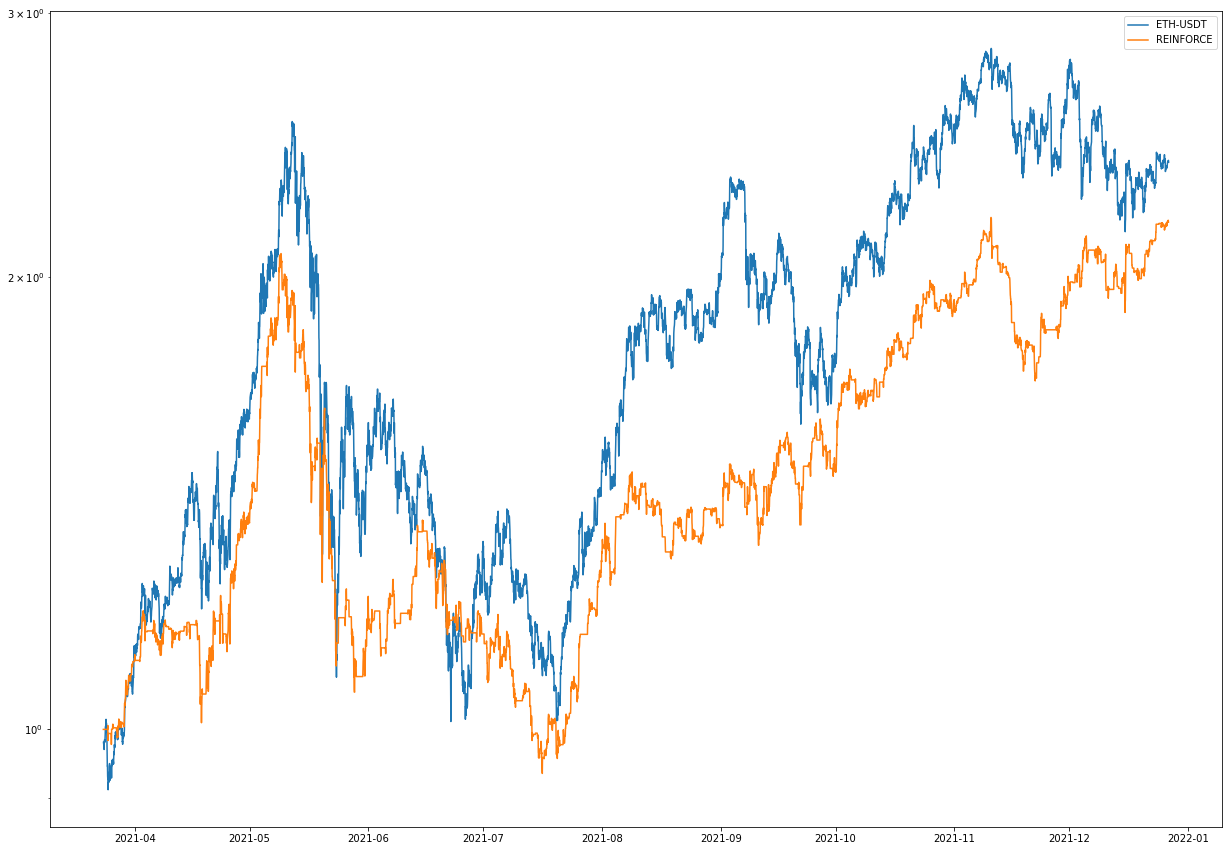

In [ ]:
test_states = test_sample.to_numpy()
ref = test_sample[['close']].copy()
ref['number'] = ref.index.map(mdates.date2num)
ref['reward'] = 1. + ref['close'].pct_change()
ref['total_reward'] = ref['reward'].cumprod()

#  Buy and hold
book = test_sample[['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.
book['total_reward'] = 1.
book['action'] = False
for i, idx in enumerate(book.index):
    state = train_states[i][5:]
    prob = pi(torch.from_numpy(state).float())
    m = Categorical(prob)
    action = m.sample().item()
    if action == 0:
        book.loc[idx, 'reward'] = 1.
    else:
        book.loc[idx, 'action'] = True
        book.loc[idx, 'reward'] = ref.shift(-1).loc[idx, 'close']/ref.loc[idx, 'close']

total_reward = 1. 
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365*24/len(book.index)) - 1.
historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.*24)
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.*24))

print("==== REINFORCE trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

plt.figure(figsize=(21, 15))
plt.yscale('log')
#for coin in samples.keys():
#    plt.plot(samples[coin].index, samples[coin].total_reward, label=coin)
plt.plot(ref.index, ref.total_reward, label="ETH-USDT")
plt.plot(book.index, book.total_reward, label="REINFORCE")
plt.legend(loc='best')

plt.show()